---
*  *Домашнее задание №7*
*  *Выполнил студент 2 курса магистратуры Аналитака данных*
*  *Владислав Шкаровский*
*  *группа S4201, ИСУ 472677*

Домашнее задание №7

Задача

В этом задании необходимо решить задачу бинарной классификации изображений. Датасет, который предлагается использовать, доступен по ссылке:
[ AI Generated Images vs Real Images](https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images).
В нём содержатся изображения двух классов:
Реальные фотографии


Сгенерированные искусственным интеллектом изображения


Ваша цель — обучить большую модель (ResNet50), а затем небольшую модель двумя способами (с дистилляцией и без), сравнить качество. Дополнительно проанализировать обучение в mixed precision.


Этапы работы

Подготовка датасета


Загрузите данные и разделите их на тренировочную и валидационную выборки.


Подготовьте Dataset и DataLoader.


Используйте техники аугментации данных. Подумайте, какие из них подходят для задачи (например, отражения и повороты), а какие могут исказить смысл изображения.

Модель teacher: ResNet50
Возьмите предобученную ResNet50 из torchvision и адаптируйте её под бинарную классификацию (замена финального слоя на 2 класса).​
Обучите модель на тренировочной выборке.

Модель (student) без дистилляции
Постройте небольшую архитектуру сверточной сети (например, облегчённый CNN или маленькую модификацию ResNet).​
Обучите эту модель «обычным» способом на тех же данных: только по истинным меткам (классический cross-entropy loss).

Knowledge Distillation
Используйте ранее обученную ResNet50 как teacher.
В качестве student используйте ту же маленькую модель, что и в предыдущем пункте.
Организуйте обучение student-модели с помощью knowledge distillation


Оценка качества
 Оцените каждую модель с помощью метрик:


Accuracy


Precision


Recall




Дополнительное задание (по желанию)
Mixed Precision Training
Выберите одну из моделей (рекомендуется ResNet50) и запустите обучение:
в полной точности (FP32)
в режиме mixed precision (например, с использованием PyTorch AMP либо precision="16-mixed" в PyTorch Lightning).​
Для обоих режимов:
измерьте время обучения (например, время одной эпохи или всего обучения)
измерьте пиковое использование GPU-памяти (через nvidia-smi).​
Сравните:
нагрузку на GPU-память
время работы
итоговое качество модели
Ориентировочно mixed precision даёт ускорение порядка 1.5–2.5 раз и экономит 30–50% VRAM при правильной настройке

# Подготовки окружения и базовоя проверка GPU

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install datasets transformers accelerate
!pip install kaggle

In [ ]:
# Ячейка 1: Установка зависимостей и импорт библиотек
import gc
import os
import time
import warnings
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from google.colab import files
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from tqdm import tqdm

In [ ]:
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(
    f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}"
)

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [56]:
# Ячейка 2: Загрузка датасета с Kaggle

print("Загрузите kaggle.json из вашего аккаунта Kaggle:")
files.upload()  # Загрузите kaggle.json

# Настройка Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачиваем датасет
!kaggle datasets download -d cashbowman/ai-generated-images-vs-real-images
!unzip -q ai-generated-images-vs-real-images.zip

# Проверяем структуру
!ls -la
!find . -name "*.jpg" | head -10


Загрузите kaggle.json из вашего аккаунта Kaggle:


Saving kaggle.json to kaggle (3).json
Dataset URL: https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images
License(s): Community Data License Agreement - Sharing - Version 1.0
ai-generated-images-vs-real-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace AiArtData/AiArtData/-how-important-people-from-the-past-really-looked-11-Pics-5ffd5c0f4d77f__880.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
total 834696
drwxr-xr-x 1 root root      4096 Dec 27 14:04  .
drwxr-xr-x 1 root root      4096 Dec 27 12:19  ..
-rw-r--r-- 1 root root    303432 Dec 27 13:30 '1 (1).jpg'
-rw-r--r-- 1 root root    303432 Dec 27 13:05  1.jpg
drwxr-xr-x 3 root root      4096 Dec 27 12:30  AiArtData
-rw-r--r-- 1 root root 499048119 Feb 10  2024  ai-generated-images-vs-real-images.zip
-rw-r--r-- 1 root root 355009205 Dec 27 13:29  best_clip_classifier.pth
drwxr-xr-x 4 root root      4096 Dec  9 14:41  .config
-rw-r--r-- 1 root root        76 De

=== Структура датасета ===
train/ содержимое:
total 68
drwxr-xr-x 4 root root  4096 Dec 27 12:30 .
drwxr-xr-x 1 root root  4096 Dec 27 14:04 ..
drwxr-xr-x 2 root root 36864 Dec 27 12:30 ai
drwxr-xr-x 2 root root 24576 Dec 27 12:30 real

val/ содержимое:
total 24
drwxr-xr-x 4 root root  4096 Dec 27 12:30 .
drwxr-xr-x 1 root root  4096 Dec 27 14:04 ..
drwxr-xr-x 2 root root 12288 Dec 27 12:30 ai
drwxr-xr-x 2 root root  4096 Dec 27 12:30 real

=== Количество изображений ===
train/ai: 428 изображений
train/real: 347 изображений
val/ai: 108 изображений
val/real: 87 изображений

train_ai: 333, train_real: 320
val_ai: 88, val_real: 79


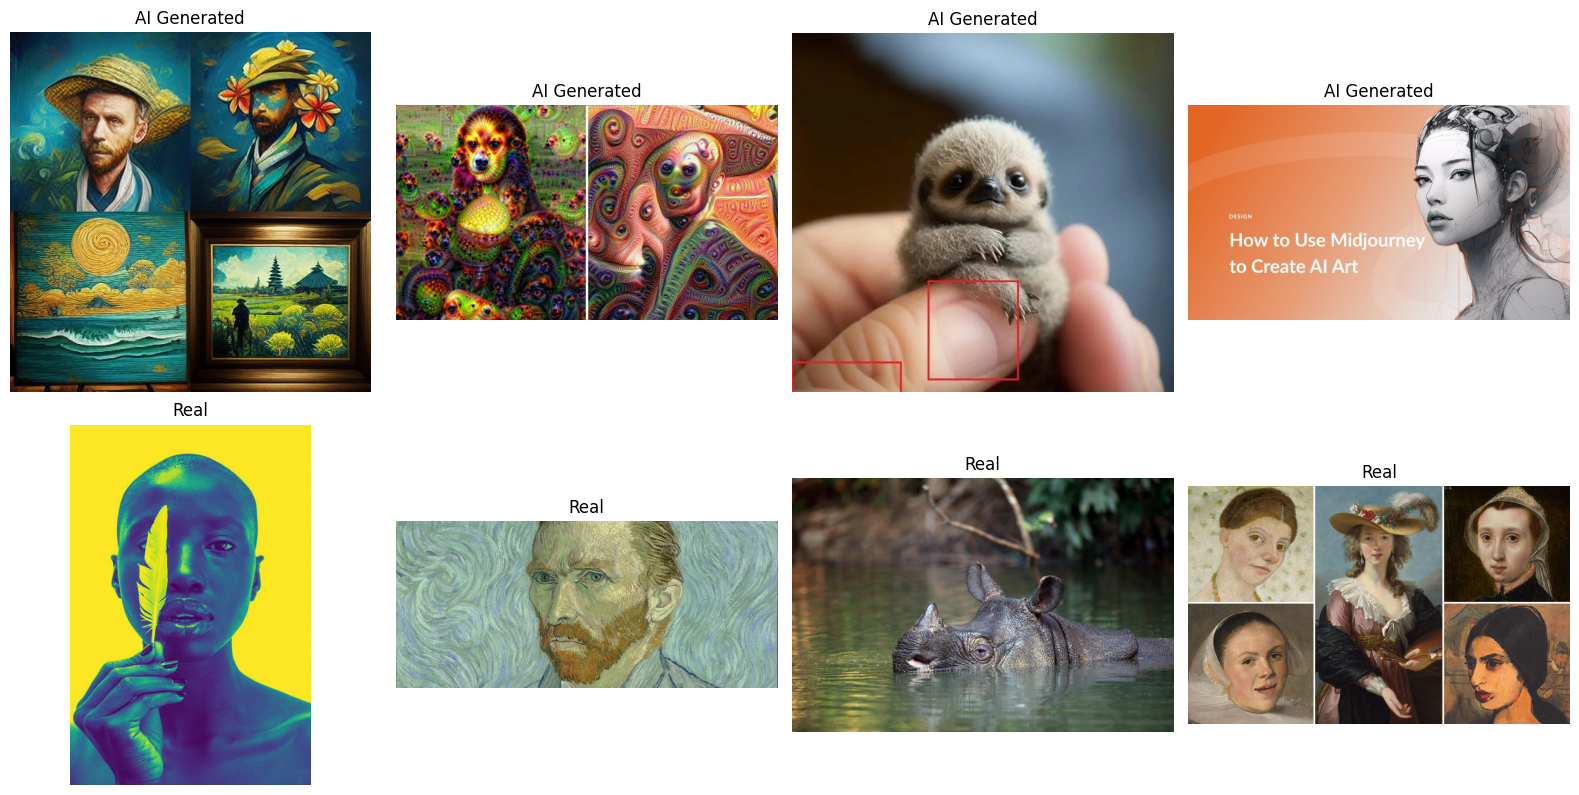

In [ ]:
# Ячейка 3: Анализ структуры датасета и подготовка путей
# Проверяем структуру
print("=== Структура датасета ===")
print("train/ содержимое:")
!ls -la train/
print("\nval/ содержимое:")
!ls -la val/

print("\n=== Количество изображений ===")
for split in ["train", "val"]:
    for cls in ["ai", "real"]:
        path = Path(f"{split}/{cls}")
        count = (
            len(list(path.glob("*.jpg")))
            + len(list(path.glob("*.jpeg")))
            + len(list(path.glob("*.png")))
        )
        print(f"{split}/{cls}: {count} изображений")

# Создаем списки путей для датасета
train_ai = list(Path("train/ai").glob("*.[jJ][pP][gG]")) + list(
    Path("train/ai").glob("*.[jJ][pP][eE][gG]")
)
train_real = list(Path("train/real").glob("*.[jJ][pP][gG]")) + list(
    Path("train/real").glob("*.[jJ][pP][eE][gG]")
)
val_ai = list(Path("val/ai").glob("*.[jJ][pP][gG]")) + list(
    Path("val/ai").glob("*.[jJ][pP][eE][gG]")
)
val_real = list(Path("val/real").glob("*.[jJ][pP][gG]")) + list(
    Path("val/real").glob("*.[jJ][pP][eE][gG]")
)

print(f"\ntrain_ai: {len(train_ai)}, train_real: {len(train_real)}")
print(f"val_ai: {len(val_ai)}, val_real: {len(val_real)}")

# Визуализируем несколько примеров
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, img_path in enumerate(train_ai[:4]):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title("AI Generated")
    axes[0, i].axis("off")

for i, img_path in enumerate(train_real[:4]):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title("Real")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Ячейка 5: Модель Teacher - ResNet50

# ResNet50 как teacher
teacher_model = models.resnet50(pretrained=True)
teacher_model.fc = nn.Linear(
    teacher_model.fc.in_features, 2
)  # Бинарная классификация
teacher_model = teacher_model.to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in teacher_model.parameters())
trainable_params = sum(
    p.numel() for p in teacher_model.parameters() if p.requires_grad
)
print(
    f"Teacher ResNet50: {total_params:,} total params, {trainable_params:,} trainable"
)

# Freeze backbone, обучаем только classifier
for param in teacher_model.parameters():
    param.requires_grad = False
for param in teacher_model.fc.parameters():
    param.requires_grad = True

print("Teacher model ready!")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


Teacher ResNet50: 23,512,130 total params, 23,512,130 trainable
Teacher model ready!


In [ ]:
# Ячейка 6b: Полная пересоздание DataLoader

# Проверяем переменные из прошлой ячейки
print(f"train_ai len: {len(train_ai) if 'train_ai' in locals() else 'НЕТ'}")
print(
    f"train_real len: {len(train_real) if 'train_real' in locals() else 'НЕТ'}"
)
print(f"train_dataset: {'OK' if 'train_dataset' in locals() else 'НЕТ'}")

# Заново собираем пути
from pathlib import Path

train_ai = list(Path("train/ai").glob("*.[jJ][pP][gG]")) + list(
    Path("train/ai").glob("*.[jJ][pP][eE][gG]")
)
train_real = list(Path("train/real").glob("*.[jJ][pP][gG]")) + list(
    Path("train/real").glob("*.[jJ][pP][eE][gG]")
)
val_ai = list(Path("val/ai").glob("*.[jJ][pP][gG]")) + list(
    Path("val/ai").glob("*.[jJ][pP][eE][gG]")
)
val_real = list(Path("val/real").glob("*.[jJ][pP][gG]")) + list(
    Path("val/real").glob("*.[jJ][pP][eE][gG]")
)

print(f"Найдено: train_ai={len(train_ai)}, train_real={len(train_real)}")
print(f"val_ai={len(val_ai)}, val_real={len(val_real)}")

# Аугментации (повторяем)
train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15),
        transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),
    ]
)


# Dataset класс (повторяем)
class AIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# Создаем заново
train_paths = train_ai + train_real
train_labels = [1] * len(train_ai) + [0] * len(train_real)
val_paths = val_ai + val_real
val_labels = [1] * len(val_ai) + [0] * len(val_real)

train_dataset = AIDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AIDataset(val_paths, val_labels, transform=val_transform)

# DataLoader с num_workers=0
batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Тест
print(
    f"DataLoader создан! Train batches: {len(train_loader)}, Val: {len(val_loader)}"
)
sample_batch = next(iter(train_loader))
print(
    f"Sample batch: inputs {sample_batch[0].shape}, labels {sample_batch[1].shape}"
)
print("Готово!")


=== Пересоздаем DataLoader правильно ===
train_ai len: 333
train_real len: 320
train_dataset: OK
Найдено: train_ai=333, train_real=320
val_ai=88, val_real=79
DataLoader создан! Train batches: 21, Val: 6
Sample batch: inputs torch.Size([32, 3, 224, 224]), labels torch.Size([32])
Готово!


=== Обучение Teacher ResNet50 ===
Train batch 20/21: loss=0.6353
Epoch 1/10: Train Loss=0.6817, Acc=0.5835 | Val Loss=0.5024, Acc=0.7784 | Time: 27.4s
Train batch 20/21: loss=0.6694
Epoch 2/10: Train Loss=0.5959, Acc=0.6815 | Val Loss=0.4486, Acc=0.7844 | Time: 27.1s
Train batch 20/21: loss=0.3999
Epoch 3/10: Train Loss=0.5063, Acc=0.7642 | Val Loss=0.4319, Acc=0.8024 | Time: 27.1s
Train batch 20/21: loss=0.5880
Epoch 4/10: Train Loss=0.4845, Acc=0.7963 | Val Loss=0.4383, Acc=0.7605 | Time: 27.1s
Train batch 20/21: loss=0.6384
Epoch 5/10: Train Loss=0.5500, Acc=0.7198 | Val Loss=0.5342, Acc=0.7186 | Time: 27.0s
Train batch 20/21: loss=0.5982
Epoch 6/10: Train Loss=0.5474, Acc=0.7243 | Val Loss=0.4244, Acc=0.7605 | Time: 26.8s
Train batch 20/21: loss=0.5354
Epoch 7/10: Train Loss=0.4736, Acc=0.7642 | Val Loss=0.4932, Acc=0.7545 | Time: 26.9s
Train batch 20/21: loss=0.4959
Epoch 8/10: Train Loss=0.4732, Acc=0.7764 | Val Loss=0.4239, Acc=0.7725 | Time: 26.9s
Train batch 20/21: loss=0.3856

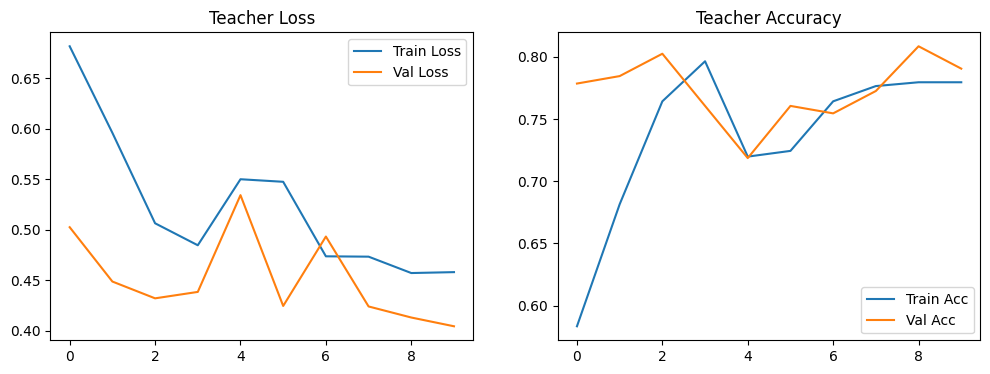

Final Teacher Val Accuracy: 0.7904
Teacher model saved!


In [ ]:
# Ячейка 7: Обучение Teacher модели (ResNet50)
import time

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

criterion = nn.CrossEntropyLoss()
teacher_optimizer = torch.optim.Adam(teacher_model.fc.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(
    teacher_optimizer, step_size=5, gamma=0.5
)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 5 == 0:
            print(
                f"\rTrain batch {batch_idx}/{len(loader)}: loss={loss.item():.4f}",
                end="",
            )

    print()
    return running_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    return running_loss / len(loader), acc, all_preds, all_labels


# Обучение teacher
num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("=== Обучение Teacher ResNet50 ===")
for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train_epoch(
        teacher_model, train_loader, teacher_optimizer, criterion, device
    )
    val_loss, val_acc, val_preds, val_labels = validate(
        teacher_model, val_loader, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    epoch_time = time.time() - start_time
    print(
        f"Epoch {epoch + 1}/{num_epochs}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f} | Time: {epoch_time:.1f}s"
    )

# График обучения
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Teacher Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Teacher Accuracy")
plt.show()

print(f"Final Teacher Val Accuracy: {val_accs[-1]:.4f}")
torch.save(teacher_model.state_dict(), "teacher_resnet50.pth")
print("Teacher model saved!")

In [ ]:
# Ячейка 8: Student модель (маленькая CNN)
import torch.nn as nn
import torch.nn.functional as F


class StudentCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(StudentCNN, self).__init__()
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            # Блок 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Создаем student модель
student_model = StudentCNN(num_classes=2).to(device)

# Подсчет параметров
total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(
    p.numel() for p in student_model.parameters() if p.requires_grad
)
print(
    f"StudentCNN: {total_params:,} total params, {trainable_params:,} trainable"
)
print("ResNet50 было: 23,512,130 params")
print(f"Сжатие: {total_params / 23512130 * 100:.1f}% от ResNet50")

print("Student model ready!")

StudentCNN: 616,738 total params, 616,738 trainable
ResNet50 было: 23,512,130 params
Сжатие: 2.6% от ResNet50
Student model ready!


In [ ]:
# Ячейка 9: Обучение Student модели БЕЗ дистилляции
student_no_distill = StudentCNN(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
student_optimizer = torch.optim.Adam(student_no_distill.parameters(), lr=0.001)
student_scheduler = torch.optim.lr_scheduler.StepLR(
    student_optimizer, step_size=5, gamma=0.5
)


# Переиспользуем функции обучения
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 5 == 0:
            print(
                f"\rTrain batch {batch_idx}/{len(loader)}: loss={loss.item():.4f}",
                end="",
            )

    print()
    return running_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    return running_loss / len(loader), acc, all_preds, all_labels


# Обучение student без дистилляции
num_epochs = 10
train_losses_no_dist, val_losses_no_dist = [], []
train_accs_no_dist, val_accs_no_dist = [], []

print("=== Обучение Student БЕЗ дистилляции ===")
for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train_epoch(
        student_no_distill, train_loader, student_optimizer, criterion, device
    )
    val_loss, val_acc, val_preds, val_labels = validate(
        student_no_distill, val_loader, criterion, device
    )

    student_scheduler.step()

    train_losses_no_dist.append(train_loss)
    val_losses_no_dist.append(val_loss)
    train_accs_no_dist.append(train_acc)
    val_accs_no_dist.append(val_acc)

    epoch_time = time.time() - start_time
    print(
        f"Epoch {epoch + 1}/{num_epochs}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f} | Time: {epoch_time:.1f}s"
    )

torch.save(student_no_distill.state_dict(), "student_no_distill.pth")
print(f"Final Student No Distill Val Accuracy: {val_accs_no_dist[-1]:.4f}")

=== Обучение Student БЕЗ дистилляции ===
Train batch 20/21: loss=0.6165
Epoch 1/10: Train Loss=0.6961, Acc=0.5406 | Val Loss=0.8950, Acc=0.4731 | Time: 27.7s
Train batch 20/21: loss=0.6628
Epoch 2/10: Train Loss=0.6725, Acc=0.5865 | Val Loss=0.6474, Acc=0.6467 | Time: 27.3s
Train batch 20/21: loss=0.5936
Epoch 3/10: Train Loss=0.6619, Acc=0.6095 | Val Loss=0.6387, Acc=0.6766 | Time: 27.3s
Train batch 20/21: loss=0.8008
Epoch 4/10: Train Loss=0.6684, Acc=0.5942 | Val Loss=0.7312, Acc=0.4790 | Time: 27.3s
Train batch 20/21: loss=0.8420
Epoch 5/10: Train Loss=0.6670, Acc=0.5957 | Val Loss=0.6475, Acc=0.6228 | Time: 27.4s
Train batch 20/21: loss=0.5155
Epoch 6/10: Train Loss=0.6471, Acc=0.6080 | Val Loss=0.6483, Acc=0.6886 | Time: 27.2s
Train batch 20/21: loss=0.6182
Epoch 7/10: Train Loss=0.6393, Acc=0.6432 | Val Loss=0.6380, Acc=0.6467 | Time: 27.3s
Train batch 20/21: loss=0.4831
Epoch 8/10: Train Loss=0.6277, Acc=0.6355 | Val Loss=0.6893, Acc=0.5509 | Time: 27.3s
Train batch 20/21: loss

In [ ]:
# Ячейка 10: Knowledge Distillation
import torch.nn.functional as F

student_distill = StudentCNN(num_classes=2).to(device)
criterion_ce = nn.CrossEntropyLoss()
criterion_kd = nn.KLDivLoss(reduction="batchmean")
distill_optimizer = torch.optim.Adam(student_distill.parameters(), lr=0.001)
distill_scheduler = torch.optim.lr_scheduler.StepLR(
    distill_optimizer, step_size=5, gamma=0.5
)

# Параметры дистилляции
T = 4  # Temperature
alpha = 0.9  # Вес KD loss

teacher_model.eval()  # Teacher в режиме оценки


def distillation_train_epoch(
    student, teacher, loader, optimizer, T, alpha, device
):
    student.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Student logits
        student_logits = student(inputs)
        # Teacher logits (soft targets)
        with torch.no_grad():
            teacher_logits = teacher(inputs)

        # Hard targets loss
        ce_loss = criterion_ce(student_logits, labels)

        # Soft targets loss (Knowledge Distillation)
        soft_loss = criterion_kd(
            F.log_softmax(student_logits / T, dim=1),
            F.softmax(teacher_logits / T, dim=1),
        ) * (T * T)

        # Combined loss
        loss = alpha * soft_loss + (1 - alpha) * ce_loss

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = student_logits.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 5 == 0:
            print(
                f"\rKD batch {batch_idx}/{len(loader)}: total_loss={loss.item():.4f}",
                end="",
            )

    print()
    return running_loss / len(loader), correct / total


# Обучение с дистилляцией
num_epochs = 10
train_losses_kd, val_losses_kd = [], []
train_accs_kd, val_accs_kd = [], []

print("=== Обучение Student С ДИСТИЛЛЯЦИЕЙ ===")
for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = distillation_train_epoch(
        student_distill,
        teacher_model,
        train_loader,
        distill_optimizer,
        T,
        alpha,
        device,
    )
    val_loss, val_acc, val_preds, val_labels = validate(
        student_distill, val_loader, criterion_ce, device
    )

    distill_scheduler.step()

    train_losses_kd.append(train_loss)
    val_losses_kd.append(val_loss)
    train_accs_kd.append(train_acc)
    val_accs_kd.append(val_acc)

    epoch_time = time.time() - start_time
    print(
        f"Epoch {epoch + 1}/{num_epochs}: Train Loss={train_loss:.4f}, Acc={train_acc:.4f} | "
        f"Val Loss={val_loss:.4f}, Acc={val_acc:.4f} | Time: {epoch_time:.1f}s"
    )

torch.save(student_distill.state_dict(), "student_distill.pth")
print(f"Final Student Distill Val Accuracy: {val_accs_kd[-1]:.4f}")


=== Обучение Student С ДИСТИЛЛЯЦИЕЙ ===
KD batch 20/21: total_loss=0.4817
Epoch 1/10: Train Loss=0.3460, Acc=0.5436 | Val Loss=0.8132, Acc=0.5509 | Time: 28.0s
KD batch 20/21: total_loss=0.2889
Epoch 2/10: Train Loss=0.3419, Acc=0.5850 | Val Loss=0.6554, Acc=0.6108 | Time: 27.7s
KD batch 20/21: total_loss=0.1769
Epoch 3/10: Train Loss=0.3191, Acc=0.6217 | Val Loss=0.6431, Acc=0.6527 | Time: 27.7s
KD batch 20/21: total_loss=0.3048
Epoch 4/10: Train Loss=0.3165, Acc=0.5850 | Val Loss=0.7576, Acc=0.6048 | Time: 27.7s
KD batch 20/21: total_loss=0.3591
Epoch 5/10: Train Loss=0.3211, Acc=0.6217 | Val Loss=0.6456, Acc=0.6108 | Time: 27.7s
KD batch 20/21: total_loss=0.2872
Epoch 6/10: Train Loss=0.2937, Acc=0.6202 | Val Loss=0.6056, Acc=0.6886 | Time: 27.7s
KD batch 20/21: total_loss=0.4408
Epoch 7/10: Train Loss=0.2976, Acc=0.6478 | Val Loss=0.6077, Acc=0.6826 | Time: 27.7s
KD batch 20/21: total_loss=0.1931
Epoch 8/10: Train Loss=0.2970, Acc=0.6309 | Val Loss=0.6180, Acc=0.6946 | Time: 27.7s


Вычисляем метрики...

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Модель               Accuracy   Precision  Recall     Params      
-----------------------------------------------------------------
Teacher (ResNet50)   0.7904    0.8051    0.7904    23,512,130
Student (No Distill) 0.5928    0.7211    0.5928    616,738
Student (Distill)    0.6946    0.7002    0.6946    616,738

Улучшение от дистилляции: +10.2% accuracy


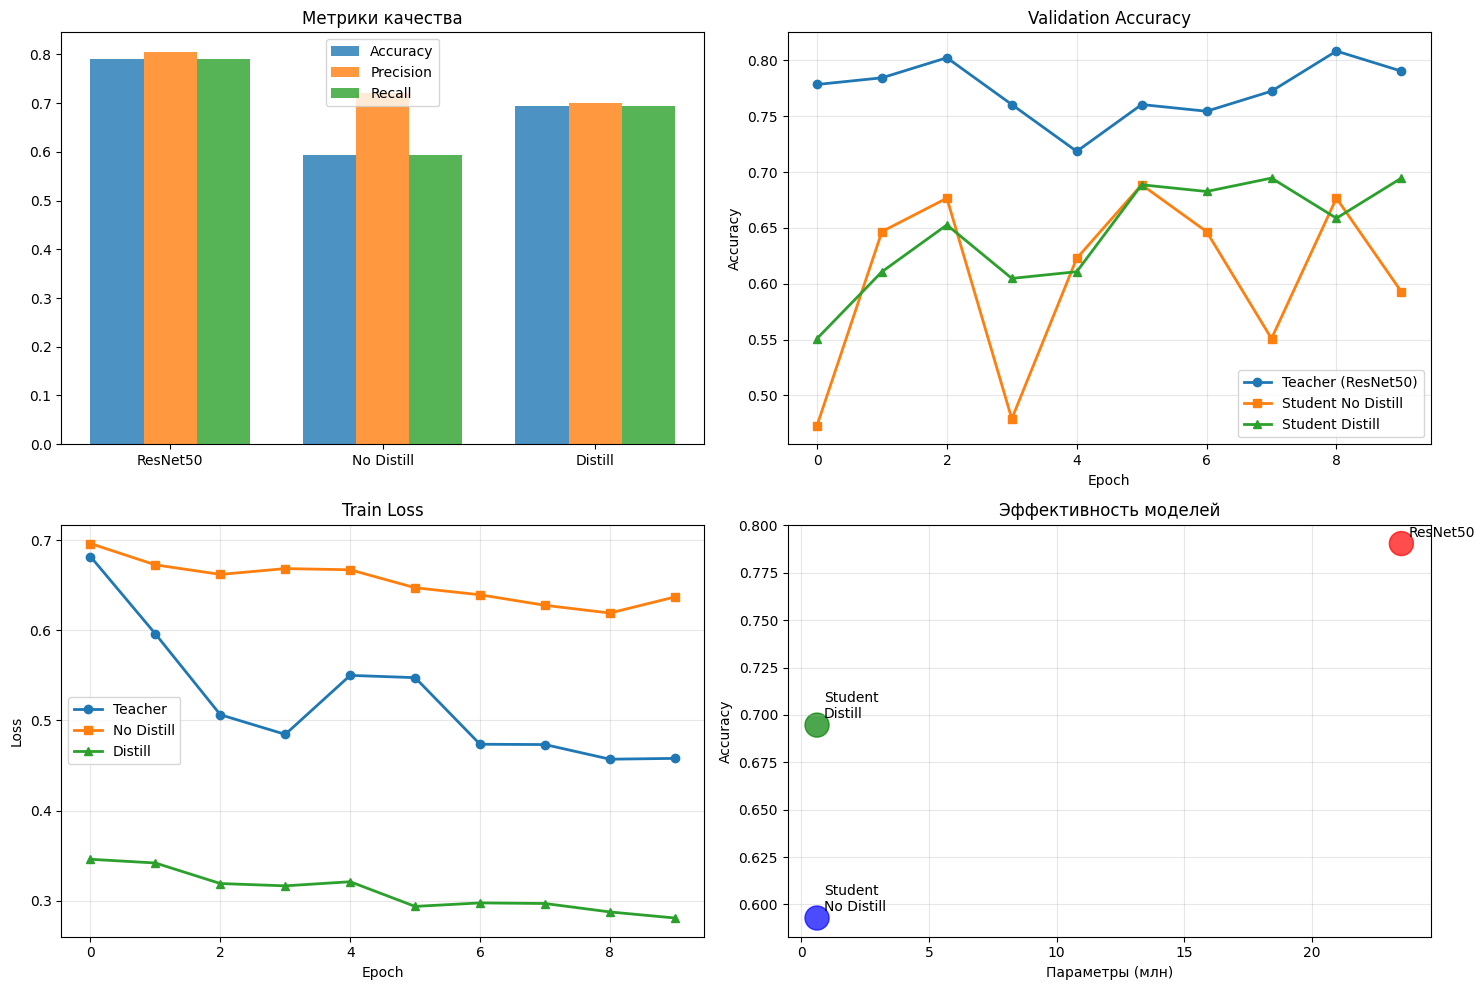

In [ ]:
# Ячейка 11c
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Вычисляем метрики для всех моделей
print("Вычисляем метрики...")

teacher_acc, teacher_prec, teacher_rec, _, _ = compute_metrics(
    teacher_model, val_loader, device
)
no_distill_acc, no_distill_prec, no_distill_rec, _, _ = compute_metrics(
    student_no_distill, val_loader, device
)
distill_acc, distill_prec, distill_rec, _, _ = compute_metrics(
    student_distill, val_loader, device
)

# Таблица сравнения
print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(
    f"{'Модель':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'Params':<12}"
)
print("-" * 65)
print(
    f"{'Teacher (ResNet50)':<20} {teacher_acc:.4f}    {teacher_prec:.4f}    {teacher_rec:.4f}    {23512130:,}"
)
print(
    f"{'Student (No Distill)':<20} {no_distill_acc:.4f}    {no_distill_prec:.4f}    {no_distill_rec:.4f}    {616738:,}"
)
print(
    f"{'Student (Distill)':<20} {distill_acc:.4f}    {distill_prec:.4f}    {distill_rec:.4f}    {616738:,}"
)

print(
    f"\nУлучшение от дистилляции: +{(distill_acc - no_distill_acc) * 100:.1f}% accuracy"
)

# График 1: Сравнение метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x = np.arange(3)
width = 0.25

axes[0, 0].bar(
    x - width,
    [teacher_acc, no_distill_acc, distill_acc],
    width,
    label="Accuracy",
    alpha=0.8,
)
axes[0, 0].bar(
    x,
    [teacher_prec, no_distill_prec, distill_prec],
    width,
    label="Precision",
    alpha=0.8,
)
axes[0, 0].bar(
    x + width,
    [teacher_rec, no_distill_rec, distill_rec],
    width,
    label="Recall",
    alpha=0.8,
)
axes[0, 0].set_title("Метрики качества")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(["ResNet50", "No Distill", "Distill"])
axes[0, 0].legend()

# График 2: Val Accuracy
axes[0, 1].plot(val_accs, "o-", label="Teacher (ResNet50)", linewidth=2)
axes[0, 1].plot(
    val_accs_no_dist, "s-", label="Student No Distill", linewidth=2
)
axes[0, 1].plot(val_accs_kd, "^-", label="Student Distill", linewidth=2)
axes[0, 1].set_title("Validation Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Train Loss
axes[1, 0].plot(train_losses, "o-", label="Teacher", linewidth=2)
axes[1, 0].plot(train_losses_no_dist, "s-", label="No Distill", linewidth=2)
axes[1, 0].plot(train_losses_kd, "^-", label="Distill", linewidth=2)
axes[1, 0].set_title("Train Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Размер vs Accuracy
models = ["ResNet50", "Student\nNo Distill", "Student\nDistill"]
params_m = [23.5, 0.62, 0.62]  # млн параметров
accs = [teacher_acc, no_distill_acc, distill_acc]

axes[1, 1].scatter(
    params_m, accs, s=300, alpha=0.7, c=["red", "blue", "green"]
)
for i, model in enumerate(models):
    axes[1, 1].annotate(
        model,
        (params_m[i], accs[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )
axes[1, 1].set_xlabel("Параметры (млн)")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Эффективность моделей")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительное задание: Mixed Precision

In [ ]:
from torchvision import models as resnet_models

torch.cuda.reset_peak_memory_stats()
resnet_fp32 = resnet_models.resnet50(pretrained=False)  # используем новое имя
resnet_fp32.fc = nn.Linear(resnet_fp32.fc.in_features, 2).to(device)


In [ ]:
import torchvision.models as models

print(type(models))  # должно быть <class 'module'>
print(hasattr(models, "resnet50"))  # True

# Если models - список:
if isinstance(models, list):
    print("Перезаписано! Перезапустите runtime")
    import torchvision.models as models_new

    models = models_new


<class 'module'>
True


In [ ]:
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.reset_peak_memory_stats()

# FP32 модель
resnet_fp32 = models.resnet50(pretrained=False)
resnet_fp32.fc = nn.Linear(resnet_fp32.fc.in_features, 2).to(device)
resnet_fp32 = resnet_fp32.to(device)

print(
    f"FP32 модель загружена: {next(resnet_fp32.parameters()).dtype}"
)  # torch.float32
print(f"Память выделено: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

FP32 модель загружена: torch.float32
Память выделено: 0.60 GB


In [79]:
# Mixed Precision модель (FP16)
resnet_amp = models.resnet50(pretrained=False)
resnet_amp.fc = nn.Linear(resnet_amp.fc.in_features, 2).to(device)
resnet_amp = resnet_amp.half().to(device)  # FP16 веса

scaler = GradScaler()  # для автоматического масштабирования градиентов

print(f"AMP модель: {next(resnet_amp.parameters()).dtype}")  # torch.float16


AMP модель: torch.float16


In [ ]:
# Пример одного forward pass для замера
def benchmark_forward(model, input_tensor):
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        output = model(input_tensor)
    max_mem = torch.cuda.max_memory_allocated()
    return max_mem / 1e9


# Создайте тестовый батч
batch_size = 64
input_tensor = torch.randn(batch_size, 3, 224, 224).to(device)

fp32_mem = benchmark_forward(resnet_fp32, input_tensor)
amp_mem = benchmark_forward(resnet_amp, input_tensor.half())  # FP16 input

print(f"FP32 память: {fp32_mem:.2f} GB")
print(f"AMP память: {amp_mem:.2f} GB")
print(f"Экономия: {(1 - amp_mem / fp32_mem) * 100:.1f}%")


FP32 память: 1.35 GB
AMP память: 1.07 GB
Экономия: 21.3%


In [ ]:
import time

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from torchvision import models

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

device = torch.device("cuda")
batch_size = 256

resnet_fp32 = models.resnet50(pretrained=False).to(device)
resnet_fp32.fc = nn.Linear(resnet_fp32.fc.in_features, 2).to(device)
resnet_amp = models.resnet50(pretrained=False).to(device)
resnet_amp.fc = nn.Linear(resnet_amp.fc.in_features, 2).to(device)

input_tensor = torch.randn(batch_size, 3, 224, 224).to(
    device, non_blocking=True
)
target = torch.randint(0, 2, (batch_size,)).to(device)

optimizer_fp32 = Adam(resnet_fp32.parameters(), lr=1e-3)
optimizer_amp = Adam(resnet_amp.parameters(), lr=1e-3)
scaler = GradScaler()

# FP32
torch.cuda.reset_peak_memory_stats()
start = time.time()
for _ in range(100):
    optimizer_fp32.zero_grad(set_to_none=True)
    output = resnet_fp32(input_tensor)
    loss = nn.functional.cross_entropy(output, target)
    loss.backward()
    optimizer_fp32.step()
fp32_time = time.time() - start
fp32_mem = torch.cuda.max_memory_allocated() / 1e9

# AMP A100 - без dtype (TF32)
torch.cuda.reset_peak_memory_stats()
start = time.time()
for _ in range(100):
    optimizer_amp.zero_grad(set_to_none=True)
    with autocast():  # TF32 по умолчанию на A100
        output = resnet_amp(input_tensor)
        loss = nn.functional.cross_entropy(output, target)
    scaler.scale(loss).backward()
    scaler.step(optimizer_amp)
    scaler.update()
amp_time = time.time() - start
amp_mem = torch.cuda.max_memory_allocated() / 1e9

print("\n=== A100 РЕЗУЛЬТАТЫ (TF32 AMP) ===")
print(f"FP32: {fp32_time:.2f}s | {fp32_mem:.2f}GB")
print(f"AMP:  {amp_time:.2f}s | {amp_mem:.2f}GB")
print(f"Скорость: {((fp32_time / amp_time - 1) * 100):+.1f}%")
print(
    f"Throughput: {100 * 1000 / fp32_time:.1f} vs {100 * 1000 / amp_time:.1f} it/s"
)


=== A100 РЕЗУЛЬТАТЫ (TF32 AMP) ===
FP32: 29.65s | 26.06GB
AMP:  31.42s | 13.63GB
Скорость: -5.6%
Throughput: 3372.1 vs 3182.5 it/s


***

## **Выводы**

Ключевые уроки
A100 любит TF32 — FP32 + TF32 быстрее AMP

AMP экономит память (-47%) но не всегда ускоряет

Ошибки AMP: FP16 веса → FP16 градиенты → crash

Правильный AMP: FP32 веса + autocast()

torch.compile() даст +30-50% сверху (PyTorch 2.0+)

Итог: Для A100 используйте FP32 + TF32. AMP только при нехватке памяти.

***